### Exercise of Factor Analysis  

#### Import libraries  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
#import japanize_matplotlib
from sklearn.preprocessing import scale

#### Parameters  

In [4]:
csv_in = 'exam_scores.csv'

%config InlineBackend.figure_formats = {'png', 'retina'}  # for high-reso graph

pd.set_option("display.max_colwidth", 200)

#### Read CSV data  

In [5]:
df = pd.read_csv(csv_in, sep=',', header=0,encoding='utf-8')
print(df.shape)
print(df.info())
display(df.head())

(1000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Eng        1000 non-null   int64
 1   Jap        1000 non-null   int64
 2   Classical  1000 non-null   int64
 3   Math       1000 non-null   int64
 4   Phys       1000 non-null   int64
 5   Geol       1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB
None


,Eng,Jap,Classical,Math,Phys,Geol
0,31,31,33,59,63,52
1,72,77,60,50,51,68
2,34,27,47,34,33,20
3,44,44,54,43,35,48
4,58,57,54,45,61,63


#### Factor analysis  

In [6]:
df_scaled = scale(df)
df_scaled = pd.DataFrame(df_scaled)
display(df_scaled)

,0,1,2,3,4,5
0,-1.188856,-1.207622,-1.068248,0.629172,0.919531,0.194706
1,1.557698,1.893859,0.743935,0.025424,0.111507,1.271176
2,-0.987889,-1.477316,-0.128598,-1.047905,-1.100528,-1.958233
3,-0.317997,-0.331117,0.341227,-0.444157,-0.965858,-0.074411
4,0.619851,0.545389,0.341227,-0.309991,0.784860,0.934779
...,...,...,...,...,...,...
995,-1.322835,-0.533387,-1.538073,-0.645406,-0.831187,-0.478087
996,-2.260683,-2.758363,-3.081785,-1.249154,-1.639211,-0.478087
997,-1.121867,-0.937928,-1.135366,-2.121234,-2.110558,-2.429188
998,-2.193693,-2.488669,-2.142134,-0.108742,-0.898522,-0.747204


#### Correlation matrix (相関行列)   

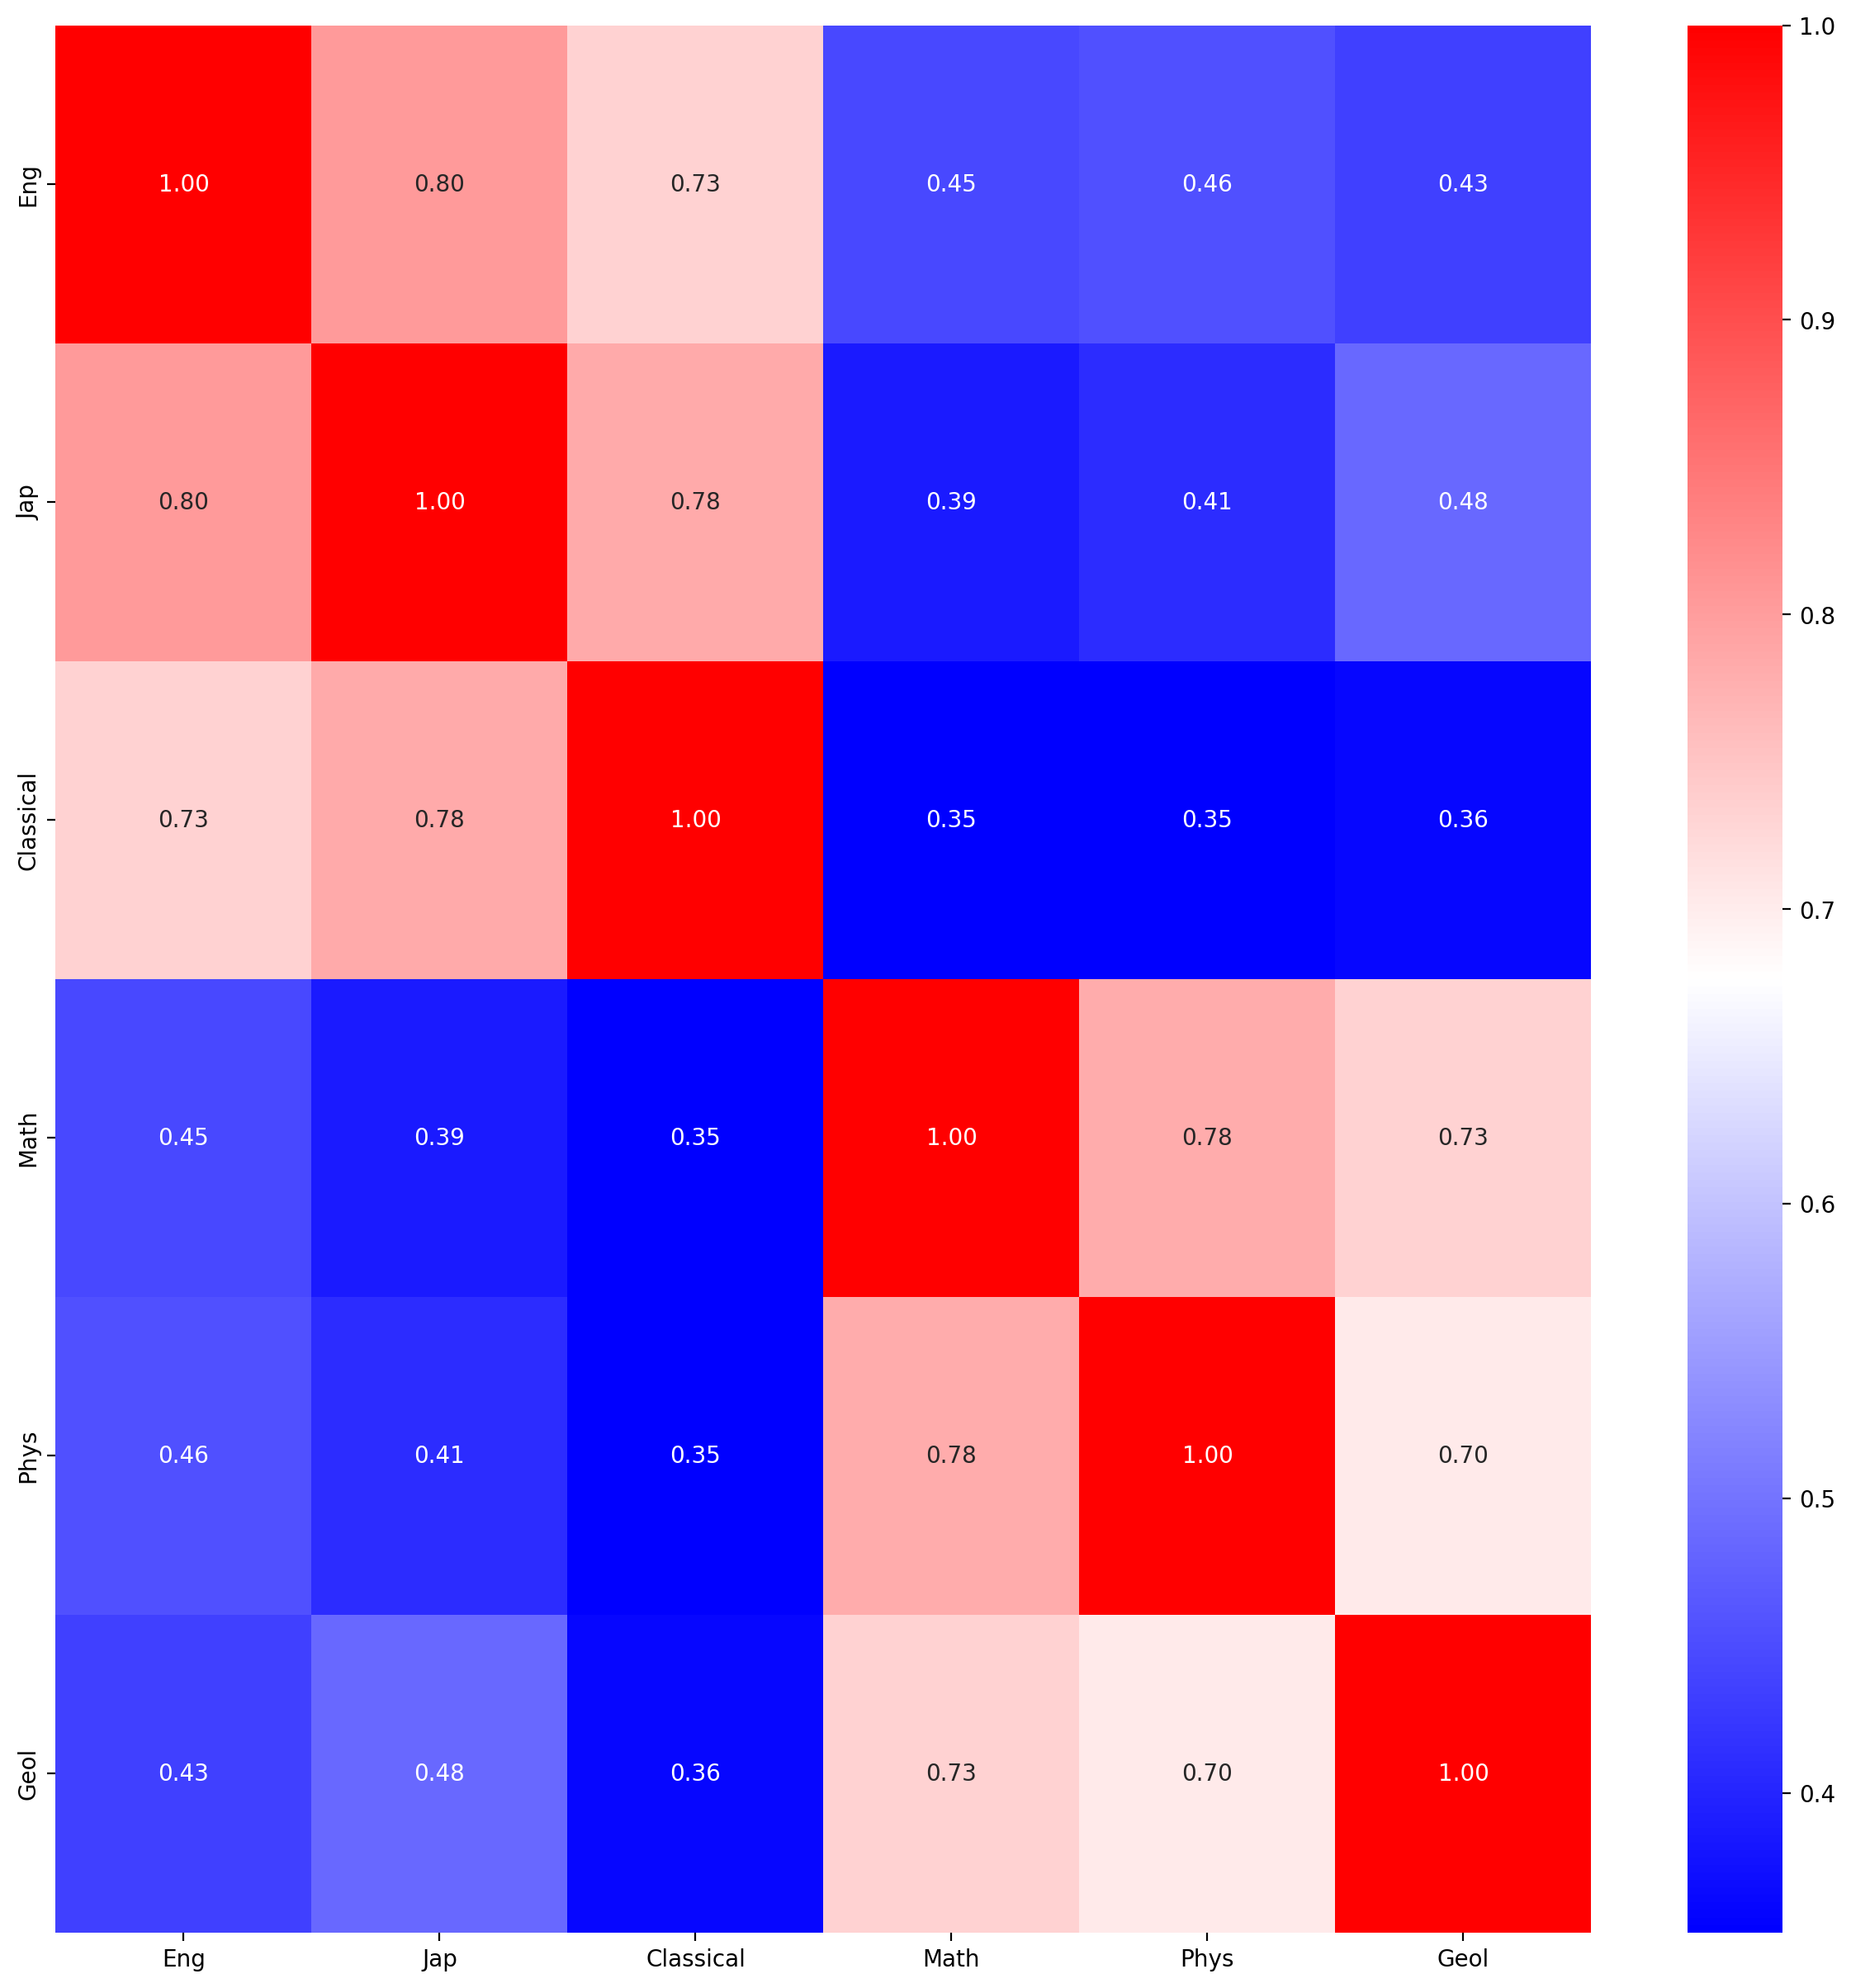

In [7]:
df_corr = df.corr(method='pearson')
plt.figure(figsize=(15,15))
sns.heatmap(df_corr,annot=True,fmt='.2f',cmap='bwr')
plt.show()

In [8]:
#Cell_3.
#相関係数行列の固有値を調べる。
import numpy.linalg as LA
import scipy as sp
df_corr_b = sp.array(df_corr)

from scipy import linalg 
print(linalg.eigvals(df_corr_b))

[3.74426358+0.j 1.29159255+0.j 0.15418355+0.j 0.32926378+0.j
 0.26178196+0.j 0.21891458+0.j]


C:\Users\honda\AppData\Local\Temp\ipykernel_18652\1376836700.py:5: DeprecationWarning: scipy.array is deprecated and will be removed in SciPy 2.0.0, use numpy.array instead
  df_corr_b = sp.array(df_corr)


In [9]:
#1より大きい固有値は2個のため、共通因子数2とする。
fa = FactorAnalyzer(n_factors=2, rotation='promax', method='ml')
fa.fit(df.values)

FactorAnalyzer(method='ml', n_factors=2, rotation_kwargs={})

In [10]:
eigen_org, eigen_cf = fa.get_eigenvalues()
ser_eigen_org = pd.Series(eigen_org)
ser_eigen_cf = pd.Series(eigen_cf)
print(ser_eigen_org)
print(ser_eigen_cf)

0    3.744264
1    1.291593
2    0.329264
3    0.261782
4    0.218915
5    0.154184
dtype: float64
0    3.506296
1    1.070140
2    0.063851
3    0.026000
4   -0.029019
5   -0.088533
dtype: float64


#### Eigenvalues (固有値)  

#### Scree plot (スクリープロット)  

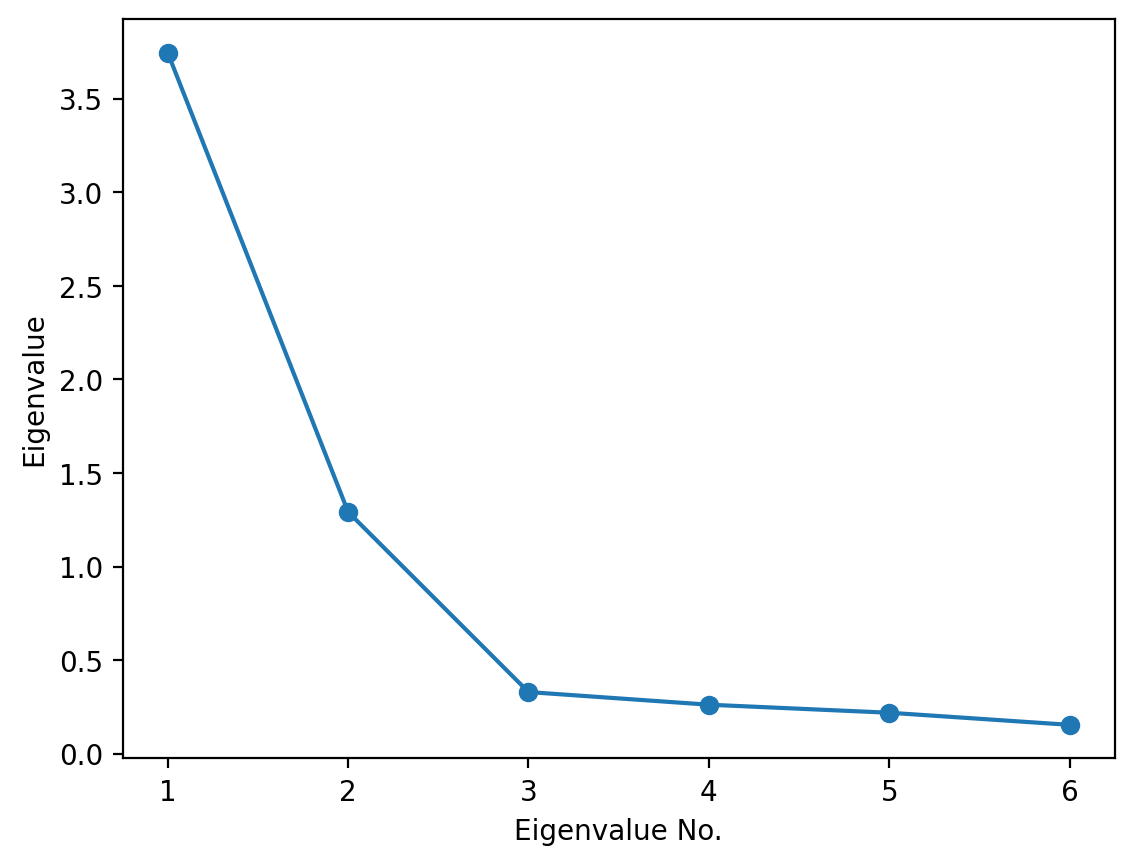

In [11]:
x = np.array(range(len(ser_eigen_org)))+1
plt.plot(x, ser_eigen_org, marker='o')
plt.xlabel('Eigenvalue No.')
plt.ylabel('Eigenvalue')
plt.show()

#### Loadings (因子負荷量)  

In [12]:
loadings = fa.loadings_
df_loadings = pd.DataFrame(loadings, index=df.columns,
                           columns=['Factor1','Factor2'])
display(df_loadings)

,Factor1,Factor2
Eng,0.819697,0.083000
Jap,0.942894,-0.017923
Classical,0.865474,-0.045087
Math,-0.060951,0.939682
Phys,-0.006442,0.866684
Geol,0.089884,0.763881


#### Scores (因子得点)  

In [13]:
scores = fa.transform(df)
df_scores = pd.DataFrame(scores, columns=['Factor1','Factor2'])
print(df_scores.shape)
display(df_scores.head())

(1000, 2)


,Factor1,Factor2
0,-1.150173,0.526277
1,1.610297,0.444375
2,-1.157366,-1.338822
3,-0.204095,-0.549049
4,0.563929,0.330973


#### Uniquenesses (独自因子の割合)  

In [14]:
uniqueness = fa.get_uniquenesses()
ser_uniqueness = pd.Series(uniqueness, index=df.columns)
print(ser_uniqueness)

Eng          0.321208
Jap          0.110630
Classical    0.248922
Math         0.113283
Phys         0.248818
Geol         0.408406
dtype: float64


#### Contribution of each factor (各共通因子の寄与)  
- Variance: 因子負荷量平方和(因子寄与)  
- Proportion Var: 寄与率  
- Cumulative Var: 累積寄与率

In [15]:
fa_var = fa.get_factor_variance()
df_fa_var = pd.DataFrame(fa_var,
                         index=['var', 'prop_var', 'cum_var'],
                         columns=['Factor1','Factor2'])
display(df_fa_var)

,Factor1,Factor2
var,2.321833,2.226901
prop_var,0.386972,0.371150
cum_var,0.386972,0.758122


#### biplot 

In [16]:
def biplot_fa(score_2d, loadings, load_labels=None):
    plt.figure(figsize=(10,10))
    r1 = 1.5
    r2 = 1.01
    if load_labels is None:
        load_labels = range(len(loadings))
    for i, coef in enumerate(loadings):
        plt.arrow(0, 0, coef[0]*r1, coef[1]*r1, color='r')    
        plt.text(coef[0]*r1*r2, coef[1]*r1*r2, load_labels[i],
                 color='b', fontsize=10)
    for i in range(len(score_2d)):
        m = '${}$'.format(i)
        plt.scatter(score_2d[i,0], score_2d[i,1], marker=m, s=500, c='k')
    plt.xlabel('F_1')
    plt.ylabel('F_2')
    plt.grid()
    return None

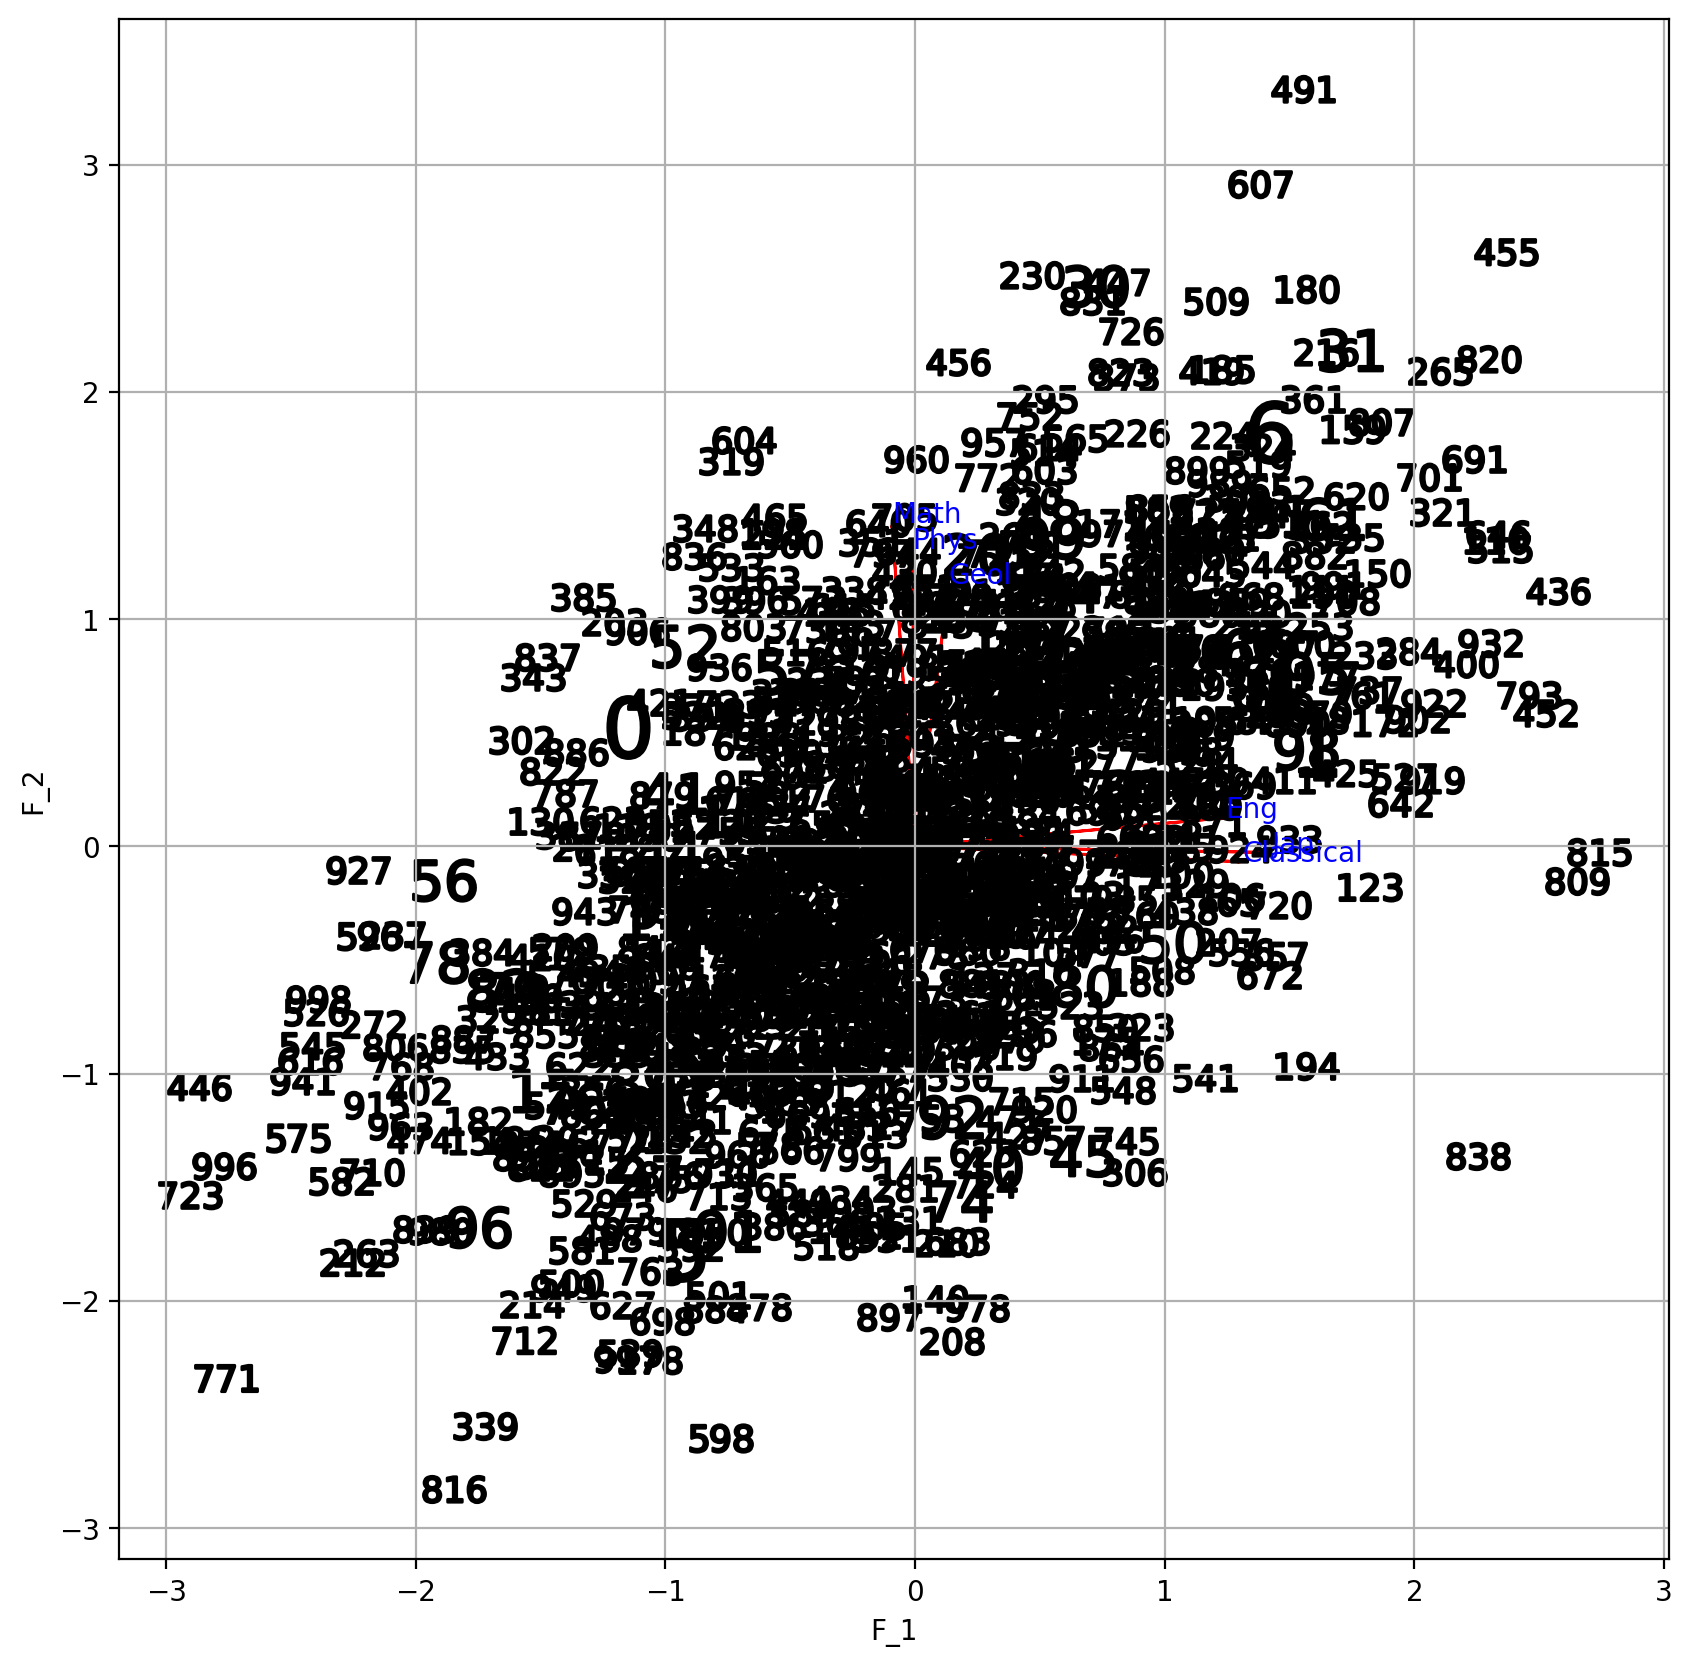

In [17]:
biplot_fa(scores, loadings, load_labels=df.columns)

In [18]:
results = []
for i in range(1, 3):
    col_name = "Factor{}".format(i)
    variables = df_loadings[col_name].abs().sort_values(ascending=False)[:3].index
    results.append([col_name, ",".join(variables)])

# Dataframe 
df_results = pd.DataFrame(results, columns=["Factor", "Top 3 Variables"])
display(df_results)

,Factor,Top 3 Variables
0,Factor1,"Jap,Classical,Eng"
1,Factor2,"Math,Phys,Geol"
